<a href="https://colab.research.google.com/github/SweetlinN/Diabetes_prediction22/blob/main/Diabetes_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.import libraries

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve,classification_report

from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

### Problem Statement - Diabetes Predictions

# 2. Data Gathering

In [5]:
# load dataset

In [6]:
from google.colab import files
uploaded = files.upload()

Saving Diabetes.csv to Diabetes.csv


In [7]:
df = pd.read_csv('Diabetes.csv')

In [8]:
# first 5 rows of the dataset

In [9]:
df.head()

,Id,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,6,148,72,35,0,33.6,0.627,50,1
1,2,1,85,66,29,0,26.6,0.351,31,0
2,3,8,183,64,0,0,23.3,0.672,32,1
3,4,1,89,66,23,94,28.1,0.167,21,0
4,5,0,137,40,35,168,43.1,2.288,33,1


In [10]:
# last five rows of the dataset

In [11]:
df.tail()

,Id,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
2763,2764,2,75,64,24,55,29.7,0.370,33,0
2764,2765,8,179,72,42,130,32.7,0.719,36,1
2765,2766,6,85,78,0,0,31.2,0.382,42,0
2766,2767,0,129,110,46,130,67.1,0.319,26,1
2767,2768,2,81,72,15,76,30.1,0.547,25,0


# 3. (EDA) Read and Explore the data

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2768 entries, 0 to 2767
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        2768 non-null   int64  
 1   Pregnancies               2768 non-null   int64  
 2   Glucose                   2768 non-null   int64  
 3   BloodPressure             2768 non-null   int64  
 4   SkinThickness             2768 non-null   int64  
 5   Insulin                   2768 non-null   int64  
 6   BMI                       2768 non-null   float64
 7   DiabetesPedigreeFunction  2768 non-null   float64
 8   Age                       2768 non-null   int64  
 9   Outcome                   2768 non-null   int64  
dtypes: float64(2), int64(8)
memory usage: 216.4 KB


In [13]:
df.describe()

,Id,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000
mean,1384.500000,3.742775,121.102601,69.134393,20.824422,80.127890,32.137392,0.471193,33.132225,0.343931
std,799.197097,3.323801,32.036508,19.231438,16.059596,112.301933,8.076127,0.325669,11.777230,0.475104
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,692.750000,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.244000,24.000000,0.000000
50%,1384.500000,3.000000,117.000000,72.000000,23.000000,37.000000,32.200000,0.375000,29.000000,0.000000
75%,2076.250000,6.000000,141.000000,80.000000,32.000000,130.000000,36.625000,0.624000,40.000000,1.000000
max,2768.000000,17.000000,199.000000,122.000000,110.000000,846.000000,80.600000,2.420000,81.000000,1.000000


In [14]:
df.isnull().sum()

,0
Id,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


# 4. Feature creation

In [15]:
df['Outcome'].value_counts()

,count
Outcome,
0,1816
1,952


In [16]:
# visualization numerical variables

In [17]:

import matplotlib.pyplot as plt
import seaborn as sns

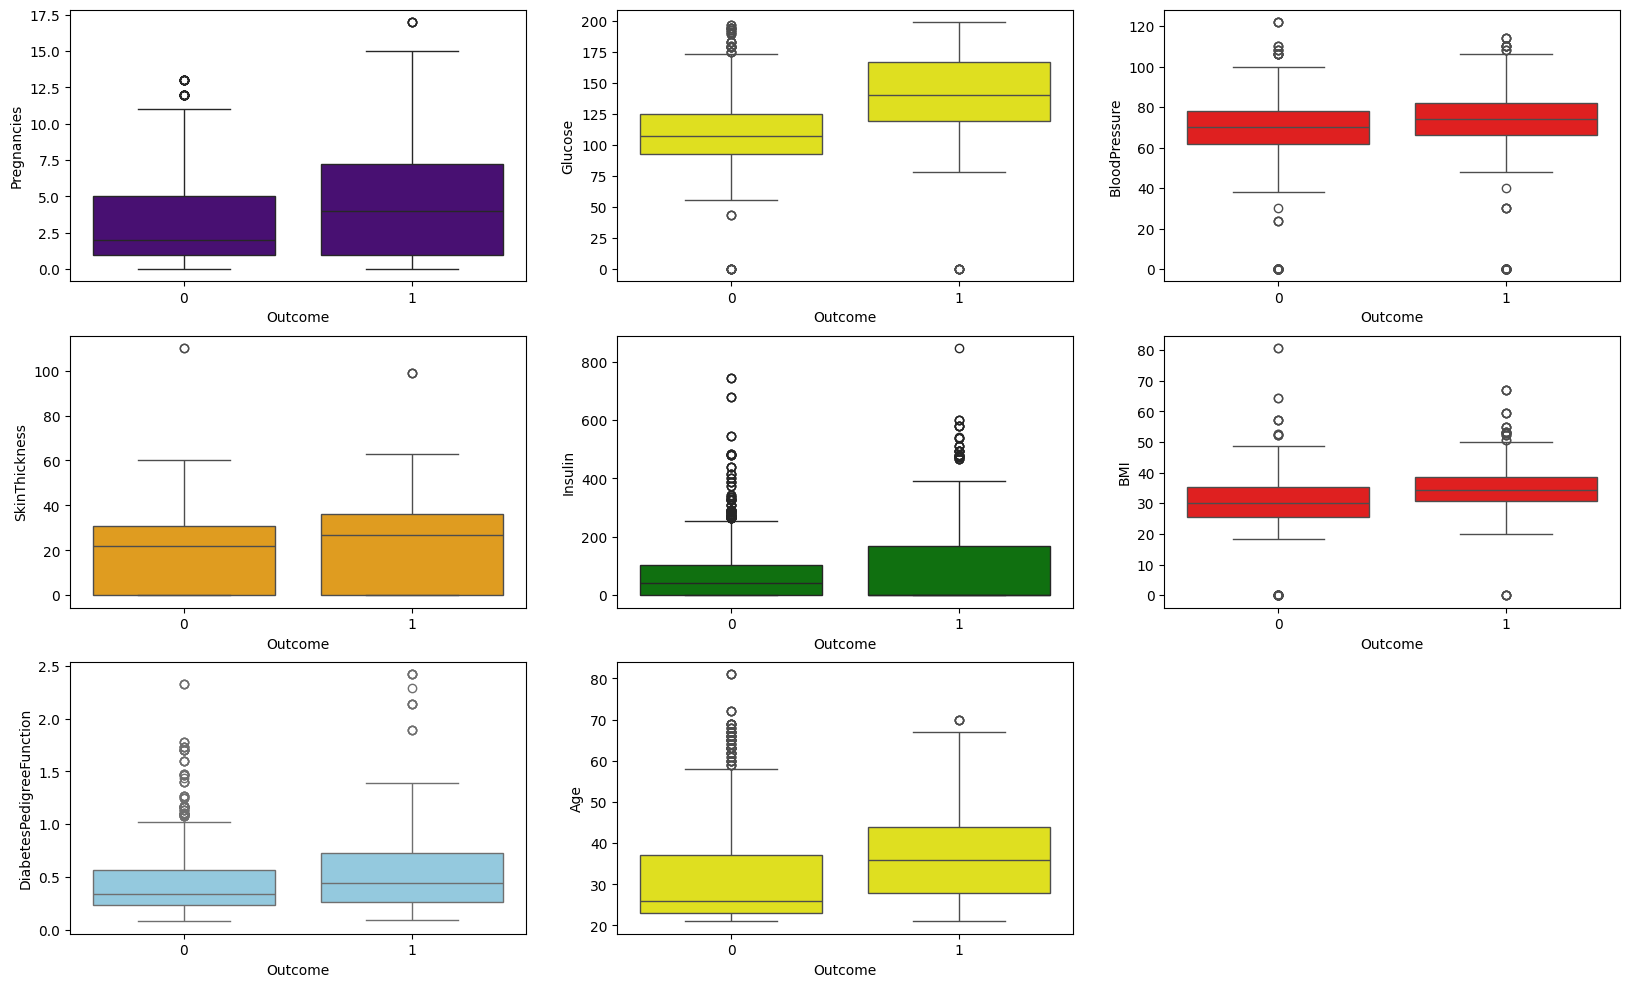

In [18]:

plt.figure(figsize=(20,12))
plt.subplot(3,3,1)
sns.boxplot(x='Outcome', y='Pregnancies',color='indigo', data=df)
plt.subplot(3,3,2)
sns.boxplot(x='Outcome',y='Glucose', data=df, color='yellow')

plt.subplot(3,3,3)
sns.boxplot(x='Outcome',y='BloodPressure', color='red', data=df)

plt.subplot(3,3,4)

sns.boxplot(x='Outcome',y='SkinThickness', data=df, color='orange')
plt.subplot(3,3,5)
sns.boxplot(x='Outcome',y='Insulin', data=df,color='green')
plt.subplot(3,3,6)
sns.boxplot(x='Outcome',y='BMI', data=df, color ='red')
plt.subplot(3,3,7)
sns.boxplot(x='Outcome', y='DiabetesPedigreeFunction',data=df,color='skyblue')
plt.subplot(3,3,8)
sns.boxplot(x='Outcome',y='Age', data=df, color='yellow')


plt.show()

In [19]:
# Subplots for All Numerical Features

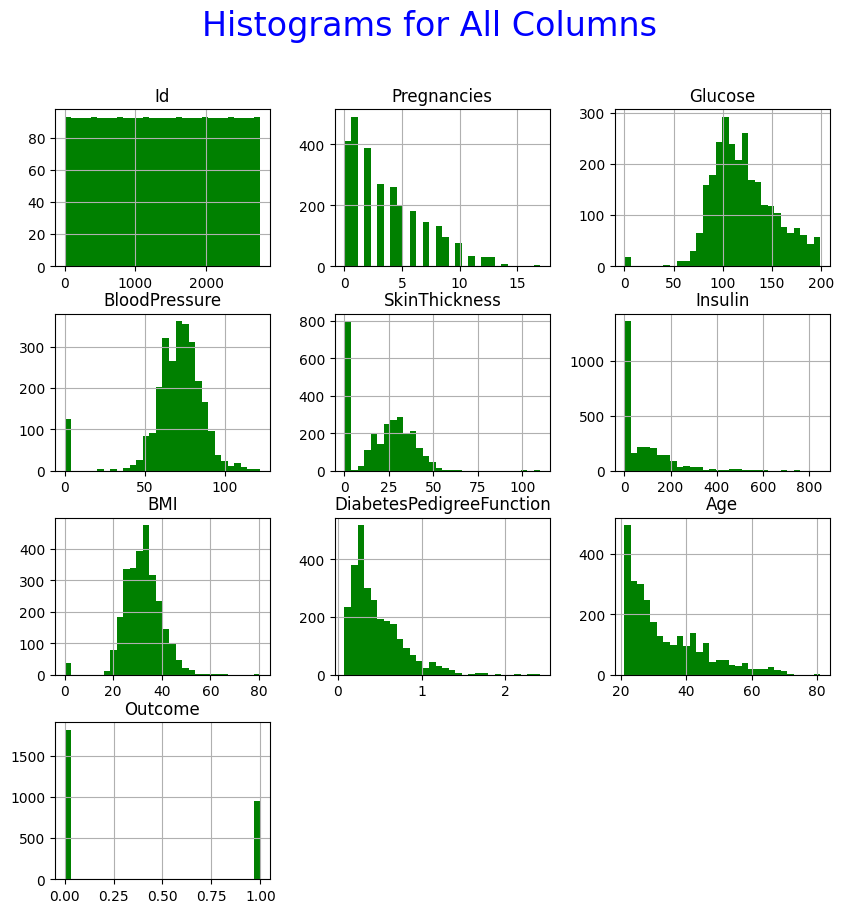

In [20]:

df.hist(figsize=(10, 10), color='green',bins=30)
plt.suptitle("Histograms for All Columns",color='blue',fontsize=24)
plt.show()

# 5. Train Test split the data

In [21]:
X=df.drop(['Outcome', 'Id'], axis=1)
y=df['Outcome']

In [22]:
X

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
2763,2,75,64,24,55,29.7,0.370,33
2764,8,179,72,42,130,32.7,0.719,36
2765,6,85,78,0,0,31.2,0.382,42
2766,0,129,110,46,130,67.1,0.319,26


In [23]:
features = X.columns.to_list()

In [24]:
print(len(features))

8


In [25]:
y

,Outcome
0,1
1,0
2,1
3,0
4,1
...,...
2763,0
2764,1
2765,0
2766,1


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 5.Fit and Evaluate model

In [27]:
def fit_and_evaluate_model(X_train,X_test,y_train,y_test,max_depth=5,min_samples_split=0.01,max_features=0.8,max_samples=0.8):
    random_forest = RandomForestClassifier(random_state=0,\
                                           max_depth=max_depth,\
                                           min_samples_split=min_samples_split,\
                                           max_features=max_features,\
                                           max_samples=max_samples)
    model = random_forest.fit(X_train,y_train)
    random_forest_predict = random_forest.predict(X_test)
    random_forest_confu_matrix = confusion_matrix(y_test,random_forest_predict)
    random_forest_acc_score = accuracy_score(y_test,random_forest_predict)
    print("confusion_matrix")
    print(random_forest_confu_matrix)
    print("\n")
    print("Accuracy of random_forest:",random_forest_acc_score*100,'\n')
    print(classification_report(y_test,random_forest_predict))
    return model

In [28]:
model  = fit_and_evaluate_model(X_train,X_test,y_train,y_test)

confusion_matrix
[[329  38]
 [ 55 132]]


Accuracy of random_forest: 83.21299638989169 

              precision    recall  f1-score   support

           0       0.86      0.90      0.88       367
           1       0.78      0.71      0.74       187

    accuracy                           0.83       554
   macro avg       0.82      0.80      0.81       554
weighted avg       0.83      0.83      0.83       554



# 6.Try different parameters to identify best one

In [29]:
param_grid = [
  {'max_depth':[3,5,7,10],
'min_samples_split':[0.01,0.03,0.07,0.1],
'max_features':[0.7,0.8,0.9,1.0],
'max_samples':[0.7,0.8,0.9,1.0]}]

In [30]:
model = RandomForestClassifier()
search = GridSearchCV(estimator = model, param_grid = param_grid,cv = 5, verbose = 5)
search.fit(X_train,y_train)

Fitting 5 folds for each of 256 candidates, totalling 1280 fits
[CV 1/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.01;, score=0.783 total time=   0.3s
[CV 2/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.01;, score=0.808 total time=   0.3s
[CV 3/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.01;, score=0.777 total time=   0.3s
[CV 4/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.01;, score=0.777 total time=   0.3s
[CV 5/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.01;, score=0.751 total time=   0.3s
[CV 1/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.03;, score=0.777 total time=   0.3s
[CV 2/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.03;, score=0.810 total time=   0.3s
[CV 3/5] END max_depth=3, max_features=0.7, max_samples=0.7, min_samples_split=0.03;, score=0.763 total time=   0.3s


GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid=[{'max_depth': [3, 5, 7, 10],
                          'max_features': [0.7, 0.8, 0.9, 1.0],
                          'max_samples': [0.7, 0.8, 0.9, 1.0],
                          'min_samples_split': [0.01, 0.03, 0.07, 0.1]}],
             verbose=5)

In [31]:
results=pd.DataFrame(search.cv_results_)
results.sort_values('mean_test_score',inplace=True, ascending=False)
results.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_max_features,param_max_samples,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
252,0.625633,0.005962,0.012922,0.001793,10,1.0,1.0,0.01,"{'max_depth': 10, 'max_features': 1.0, 'max_sa...",0.950339,0.941309,0.936795,0.902935,0.932127,0.932701,0.016052,1
220,0.518334,0.012697,0.012784,0.000908,10,0.8,1.0,0.01,"{'max_depth': 10, 'max_features': 0.8, 'max_sa...",0.948081,0.954853,0.932280,0.891648,0.920814,0.929535,0.022379,2
200,0.548236,0.094689,0.015958,0.003465,10,0.7,0.9,0.01,"{'max_depth': 10, 'max_features': 0.7, 'max_sa...",0.950339,0.939052,0.945824,0.889391,0.920814,0.929084,0.022250,3
236,0.567650,0.006804,0.012544,0.000473,10,0.9,1.0,0.01,"{'max_depth': 10, 'max_features': 0.9, 'max_sa...",0.939052,0.948081,0.932280,0.884876,0.932127,0.927283,0.021990,4
248,0.629027,0.041025,0.013129,0.001750,10,1.0,0.9,0.01,"{'max_depth': 10, 'max_features': 1.0, 'max_sa...",0.941309,0.941309,0.934537,0.900677,0.918552,0.927277,0.015686,5
204,0.454804,0.008472,0.012179,0.000140,10,0.7,1.0,0.01,"{'max_depth': 10, 'max_features': 0.7, 'max_sa...",0.952596,0.939052,0.925508,0.893905,0.920814,0.926375,0.019668,6
228,0.568604,0.062698,0.013392,0.002367,10,0.9,0.8,0.01,"{'max_depth': 10, 'max_features': 0.9, 'max_sa...",0.945824,0.936795,0.925508,0.889391,0.923077,0.924119,0.019188,7
232,0.552766,0.018411,0.012257,0.000221,10,0.9,0.9,0.01,"{'max_depth': 10, 'max_features': 0.9, 'max_sa...",0.950339,0.936795,0.927765,0.884876,0.918552,0.923665,0.022052,8
216,0.500034,0.004252,0.012376,0.000303,10,0.8,0.9,0.01,"{'max_depth': 10, 'max_features': 0.8, 'max_sa...",0.941309,0.943567,0.918736,0.891648,0.920814,0.923215,0.018782,9
244,0.759285,0.110153,0.016112,0.003346,10,1.0,0.8,0.01,"{'max_depth': 10, 'max_features': 1.0, 'max_sa...",0.934537,0.941309,0.920993,0.887133,0.918552,0.920505,0.018695,10


In [32]:
results_save = pd.DataFrame(search.cv_results_)
results_save.to_csv("results_save.csv",index=False)

In [33]:
search.best_params_

{'max_depth': 10,
 'max_features': 1.0,
 'max_samples': 1.0,
 'min_samples_split': 0.01}

# 7.Evaluate with the best parameter

#

In [34]:
model = fit_and_evaluate_model(X_train,X_test,y_train,y_test,max_depth=10,min_samples_split=0.01,\
                               max_features=0.7,max_samples=1.0)

confusion_matrix
[[352  15]
 [ 22 165]]


Accuracy of random_forest: 93.32129963898917 

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       367
           1       0.92      0.88      0.90       187

    accuracy                           0.93       554
   macro avg       0.93      0.92      0.92       554
weighted avg       0.93      0.93      0.93       554



In [35]:
# save the model

In [36]:
import joblib

In [37]:
joblib.dump(model,"Diabetes_prediction.pkl")

['Diabetes_prediction.pkl']

In [38]:
model = joblib.load("Diabetes_prediction.pkl")

In [39]:
joblib.dump(features,"features.pkl")

['features.pkl']

In [40]:
features1 = joblib.load("features.pkl")